## STEP 1- IMPORT LIBRARIES

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.model_selection import train_test_split

## Step 2- Create a Synthetic Dataset

In [3]:
np.random.seed(42)
"""Creates 100 random numbers between 0 and 1.
2 * np.random.rand"""
X = 2 * np.random.rand(100,1)
y = 3 * X + 4 + np.random.randn(100,1)  #y=3x+noise
#np.random.randn
#Adds random noise to simulate real-world data.

## STEP 3- Convert to Data

NumPy .flatten() Method

The .flatten() method in NumPy is used to convert a multi-dimensional array into a one-dimensional array. It always returns a copy of the original array, meaning changes to the flattened array will not affect the original data.

In [4]:
data = pd.DataFrame({
    "Feature": X.flatten(),
    "Target": y.flatten()
})

print(data.head())

    Feature    Target
0  0.749080  6.334288
1  1.901429  9.405278
2  1.463988  8.483724
3  1.197317  5.604382
4  0.312037  4.716440


## Step 4 — Visualize the Data

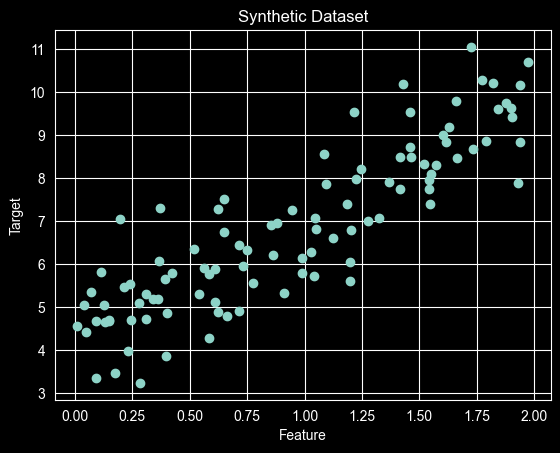

In [5]:
plt.scatter(X, y)
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Synthetic Dataset")
plt.show()

## Step 5 — Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#random_state = 42 (Ensures same split every run (important for reproducibility).

## Step 6 — Train Linear Regression

In [7]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Step 7 — Train Ridge Regression

Ridge uses L2 regularization.

It penalizes large coefficients.

### Alpha

alpha controls regularization strength.

Higher alpha → stronger penalty.

In [8]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


## Step 8 — Train Lasso Regression

Lasso uses L1 regularization.

It can push coefficients to zero.

Lasso is useful for feature selection.

In [9]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


## Step 9 — Compare Coefficients

In [10]:
print("Linear Regression Coefficient:", linear_model.coef_)
print("Ridge Coefficient:", ridge_model.coef_)
print("Lasso Coefficient:", lasso_model.coef_)

Linear Regression Coefficient: [[2.79932366]]
Ridge Coefficient: [2.69985029]
Lasso Coefficient: [2.50457141]


Interpretation

Linear regression → normal coefficient

Ridge → slightly smaller coefficient

Lasso → may shrink coefficient further

Regularization controls model complexity.

## Step 10 — Plot Regression Lines


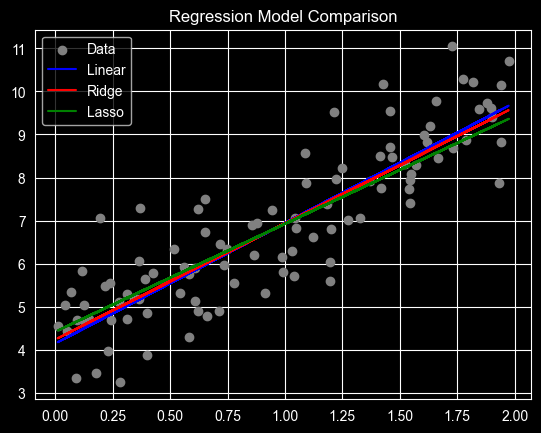

In [17]:
plt.scatter(X, y, color='gray', label="Data")

plt.plot(X, linear_model.predict(X), color='blue', label="Linear")
plt.plot(X, ridge_model.predict(X), color='red', label="Ridge")
plt.plot(X, lasso_model.predict(X), color='green', label="Lasso")

plt.legend()
plt.title("Regression Model Comparison")
plt.show()

## 🧠 Key Concept to Remember
Linear Regression- No penalty on coefficients.

Ridge- Penalizes large coefficients.

Lasso- Penalizes and can remove features.


### What changed after regularization?

Regularization methods such as Ridge and Lasso modify the regression model by adding a penalty term to the cost function. This penalty discourages the model from assigning excessively large values to the coefficients.

Ridge regression uses L2 regularization, which reduces coefficient magnitude but does not eliminate features. It helps stabilize the model and reduce overfitting.

Lasso regression uses L1 regularization, which can shrink coefficients to zero. This property makes Lasso useful for feature selection because it can remove less important features.

In our experiment, the coefficients from Ridge and Lasso were slightly smaller than those from standard Linear Regression. This demonstrates how regularization controls model complexity and helps improve generalization.

# SESSION- MODEL EVALUATION

We will calculate:

MAE (Mean Absolute Error)

MSE (Mean Squared Error)

RMSE (Root Mean Squared Error)

R² Score

Then we will create a Residual Plot.

### Step 1 — Import Evaluation Metrics

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

### Step 2 — Make Predictions

In [12]:
y_pred_linear = linear_model.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

## Step 3 — Calculate Evaluation Metrics

### Linear regression

In [13]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MAE:", mae_linear)
print("MSE:", mse_linear)
print("RMSE:", rmse_linear)
print("R2:", r2_linear)

Linear Regression
MAE: 0.5913425779189777
MSE: 0.6536995137170021
RMSE: 0.8085168605026132
R2: 0.8072059636181392


### Ridge Regression

In [14]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\nRidge Regression")
print("MAE:", mae_ridge)
print("MSE:", mse_ridge)
print("RMSE:", rmse_ridge)
print("R2:", r2_ridge)


Ridge Regression
MAE: 0.5721538047201141
MSE: 0.647613237305426
RMSE: 0.8047442061334931
R2: 0.8090009745846479


### Lasso Regression

In [15]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\nLasso Regression")
print("MAE:", mae_lasso)
print("MSE:", mse_lasso)
print("RMSE:", rmse_lasso)
print("R2:", r2_lasso)


Lasso Regression
MAE: 0.5533392824842893
MSE: 0.6584189249611411
RMSE: 0.811430172572564
R2: 0.8058140789310452


### Step 4 — Create Residual Plot

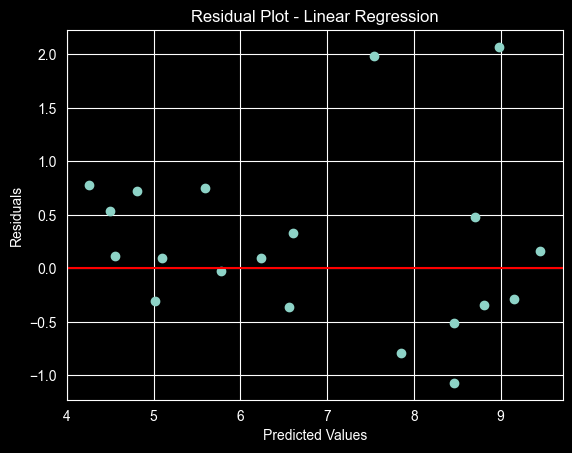

In [16]:
residuals = y_test - y_pred_linear

plt.scatter(y_pred_linear, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")
plt.show()

In [18]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso"],
    "MAE": [mae_linear, mae_ridge, mae_lasso],
    "MSE": [mse_linear, mse_ridge, mse_lasso],
    "RMSE": [rmse_linear, rmse_ridge, rmse_lasso],
    "R2 Score": [r2_linear, r2_ridge, r2_lasso]
})

print(results)

               Model       MAE       MSE      RMSE  R2 Score
0  Linear Regression  0.591343  0.653700  0.808517  0.807206
1              Ridge  0.572154  0.647613  0.804744  0.809001
2              Lasso  0.553339  0.658419  0.811430  0.805814


#### What changed after regularization?

Regularization methods such as Ridge and Lasso add a penalty term to the regression cost function to prevent the model from learning excessively large coefficients. This helps reduce overfitting and improves generalization on unseen data.

Ridge regression applies L2 regularization, which shrinks the coefficients but keeps all features in the model. This makes the model more stable while maintaining all predictors.

Lasso regression uses L1 regularization, which can shrink some coefficients to exactly zero. This makes Lasso useful for feature selection because it automatically removes less important features.

In this experiment, the predictions of Ridge and Lasso were very similar to Linear Regression because the dataset was simple and contained only one feature. However, in real-world datasets with many features, regularization plays a crucial role in controlling model complexity and improving performance.